# SPEND Initiative ML Engineer Skills Exercise

*   This notebook builds a baseline text classification pipeline to classify school district financial ledger descriptions as either Personnel or Non-Personnel expenses.

*   The workflow includes data inspection, text preprocessing, train/test splitting, TF-IDF vectorization, baseline linear classification, and model evaluation.

## 1. Load the Data

*   The provided CSV file contains raw financial ledger descriptions and a binary target category.

In [ ]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("../data/sample_ledger_expenses.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (500, 2)


,raw_text,category
0,ELEC BILL FY24,Non-Personnel
1,MATH SPEC STIPEND BLDG 2,Personnel
2,CONS FEES LOC 22,Non-Personnel
3,COPIER LEASE Q2,Non-Personnel
4,POSTAGE RM 205,Non-Personnel


## 2. Initial Data Inspection

*   Before modeling, I check the schema, missing values, class distribution, and sample records.

In [218]:
print("Columns:")
print(df.columns)

print("\nMissing values:")
print(df.isna().sum())

print("\nCategory distribution:")
print(df["category"].value_counts())

print("\nSample rows:")
display(df.sample(10, random_state=42))

Columns:
Index(['raw_text', 'category'], dtype='object')

Missing values:
raw_text    0
category    0
dtype: int64

Category distribution:
category
Non-Personnel    252
Personnel        248
Name: count, dtype: int64

Sample rows:


,raw_text,category
361,TCHR APPREC LUNCHEON,Non-Personnel
73,TEACHER-LIFE INSURANCE RM 101,Personnel
374,MATH SPEC - PAY BLDG 2,Personnel
155,PROP INS PREM RENEWAL,Non-Personnel
104,SCI LAB SUPPL,Non-Personnel
394,COORD STPND ACCT 1100,Personnel
377,MIL REIMB SCH 04,Non-Personnel
124,TEACH SAL ELEM LOC 22,Personnel
68,SCH PSYCH STIPEND - JUL,Personnel
450,GOOGLE WKSPC LIC - NOV,Non-Personnel


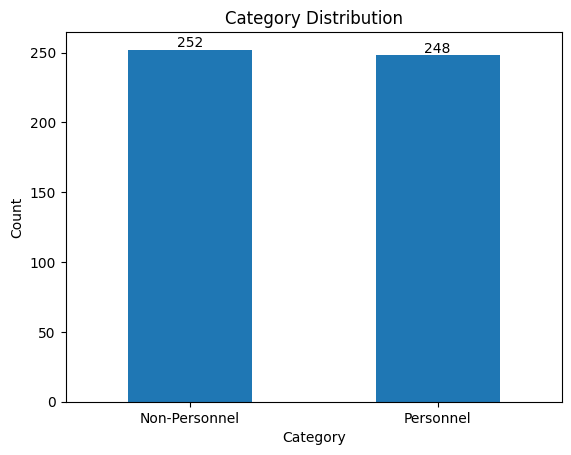

In [219]:
ax = df["category"].value_counts().plot(
    kind="bar",
    title="Category Distribution"
)

ax.set_xlabel("Category")
ax.set_ylabel("Count")
plt.xticks(rotation=0)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.show()

## 3. Duplicate Handling

*   I check for exact duplicate rows. Removing exact duplicates helps reduce the chance that the same record appears in both the training and test sets.

In [220]:
print("Number of exact duplicate rows:", df.duplicated().sum())
print("Number of duplicated raw_text values:", df["raw_text"].duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after dropping exact duplicates:", df.shape)

Number of exact duplicate rows: 5
Number of duplicated raw_text values: 5
Shape after dropping exact duplicates: (495, 2)


## 4. Review Examples by Category

*   I inspect examples from both target classes to identify common abbreviations and text patterns.

In [221]:
print("Personnel examples:")
display(df[df["category"] == "Personnel"].sample(10, random_state=1))

print("Non-Personnel examples:")
display(df[df["category"] == "Non-Personnel"].sample(10, random_state=1))

Personnel examples:


,raw_text,category
122,KITCHEN STAFF OT - SEP,Personnel
493,CUSTODIAN BONUS ACCT 5410,Personnel
407,WC INS PREM Q3,Personnel
444,SPEECH PATH HOURLY ACCT 5410,Personnel
176,EMPLR FICA SCH 04,Personnel
442,OCCUP THER / HRLY 102,Personnel
108,SUB NURSE BLDG a,Personnel
248,RET CONTRIB / ADMIN ASST ACCT 1100,Personnel
352,WC INS PREM-COUNS FY24,Personnel
13,SPECIAL ED TCHR - OVR TIME ACCT 2200,Personnel


Non-Personnel examples:


,raw_text,category
145,ASSESSMNT MAT 215,Non-Personnel
494,PRINT JOB,Non-Personnel
425,REFUSE SVC LOC 015,Non-Personnel
448,PAPER GOODS - CAF - JUL,Non-Personnel
189,BUS RPR - AUG,Non-Personnel
446,INET SVC BLDG 2,Non-Personnel
130,PAPER REAM acct 5410,Non-Personnel
259,CANVA LIC RM 12B,Non-Personnel
366,MAINT SUPPL Q3.,Non-Personnel
5,TRASH Q1,Non-Personnel


## 5. Text Preprocessing

*   The preprocessing function normalizes each raw ledger description by lowercasing text, replacing punctuation with spaces, mapping selected domain abbreviations, and removing extra whitespace.
*   I selected only abbreviations that were relatively unambiguous in the dataset. I avoided mapping ambiguous tokens such as "**sub**" and "**suppl**" because their meanings depend on context. For example, "sub" may refer to either substitute personnel or software subscriptions, while "suppl" may refer to either supplies or supplemental pay.

In [222]:
import string

ABBREVIATION_MAP = {
    "tchr": "teacher",
    "teachr": "teacher",
    "stpnd": "stipend",
    "rpr": "repair",
    "svc": "service",
    "wkr": "worker",
    "emplr": "employer",
    "sal": "salary"
}

def preprocess_text(text):
    """
    Normalize a raw ledger description string.

    Steps:
    1. Convert to lowercase.
    2. Replace punctuation with spaces.
    3. Map selected domain abbreviations to standardized terms.
    4. Collapse extra whitespace.
    """
    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Replace punctuation with spaces so tokens do not get merged.
    text = text.translate(str.maketrans(string.punctuation, " " * len(string.punctuation)))

    tokens = text.split()

    normalized_tokens = [
        ABBREVIATION_MAP.get(token, token)
        for token in tokens
    ]

    return " ".join(normalized_tokens)

## 6. Test the Preprocessing Function

*   I test the preprocessing function on examples with mixed capitalization, punctuation, and domain-specific abbreviations.

In [223]:
examples = [
    "TITLE 1 TCHR OT pay K-5 BLDG 2",
    "FACILITY RPR FY26",
    "HVAC SVC Q1",
    "MENTOR TCHR STPND FY26"
]

for example in examples:
    print("Original: ", example)
    print("Cleaned:  ", preprocess_text(example))
    print()

Original:  TITLE 1 TCHR OT pay K-5 BLDG 2
Cleaned:   title 1 teacher ot pay k 5 bldg 2

Original:  FACILITY RPR FY26
Cleaned:   facility repair fy26

Original:  HVAC SVC Q1
Cleaned:   hvac service q1

Original:  MENTOR TCHR STPND FY26
Cleaned:   mentor teacher stipend fy26



*   The cleaned text column is created for inspection only. This preprocessing step is deterministic and does not learn any parameters from the data.
*   For modeling, the train/test split is performed before fitting the TF-IDF vectorizer. The vectorizer is placed inside the sklearn Pipeline, so vocabulary and IDF weights are learned only from the training data.






In [224]:
df["clean_text"] = df["raw_text"].apply(preprocess_text)

df[["raw_text", "clean_text", "category"]].sample(10, random_state=42)

,raw_text,clean_text,category
456,RDG COACH / LIFE INS ACCT 6120,rdg coach life ins acct 6120,Personnel
73,TEACHER-LIFE INSURANCE RM 101,teacher life insurance rm 101,Personnel
310,TRANSL SVC 47,transl service 47,Non-Personnel
175,TRACK COACH STIPEND,track coach stipend,Personnel
333,BINDERS - SEP,binders sep,Non-Personnel
204,OFF SUPPL LOC 015,off suppl loc 015,Non-Personnel
155,PROP INS PREM RENEWAL,prop ins prem renewal,Non-Personnel
55,WTR SVC - AUG,wtr service aug,Non-Personnel
320,CANVA LIC FY26,canva lic fy26,Non-Personnel
9,MILK Q4,milk q4,Non-Personnel


## 7. Train/Test Split

*   I split the cleaned text and target labels into training and test sets before fitting the TF-IDF vectorizer. This prevents data leakage because the vectorizer learns vocabulary and IDF weights only from the training data.


In [225]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

print("\nTraining category distribution:")
print(y_train.value_counts())

print("\nTest category distribution:")
print(y_test.value_counts())

Training set size: 396
Test set size: 99

Training category distribution:
category
Non-Personnel    198
Personnel        198
Name: count, dtype: int64

Test category distribution:
category
Non-Personnel    50
Personnel        49
Name: count, dtype: int64


## 8. Model Pipeline

*   I use a TF-IDF vectorizer with unigram and bigram features, followed by a baseline Logistic Regression classifier. This creates a simple, reproducible, and interpretable text classification pipeline.

In [226]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

model.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
                ('clf', LogisticRegression(max_iter=1000, random_state=42))])

## 9. Model Evaluation

*   I evaluate the trained pipeline on the held-out test set and report precision, recall, and F1-score for both target classes.
*   The confusion matrix below provides a visual summary of correct and incorrect predictions across the two target classes.



In [227]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

labels = ["Non-Personnel", "Personnel"]

cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {label}" for label in labels],
    columns=[f"Predicted {label}" for label in labels]
)

print("Confusion Matrix:")
display(cm_df)

Classification Report:
               precision    recall  f1-score   support

Non-Personnel       0.91      0.86      0.89        50
    Personnel       0.87      0.92      0.89        49

     accuracy                           0.89        99
    macro avg       0.89      0.89      0.89        99
 weighted avg       0.89      0.89      0.89        99

Confusion Matrix:


,Predicted Non-Personnel,Predicted Personnel
Actual Non-Personnel,43,7
Actual Personnel,4,45


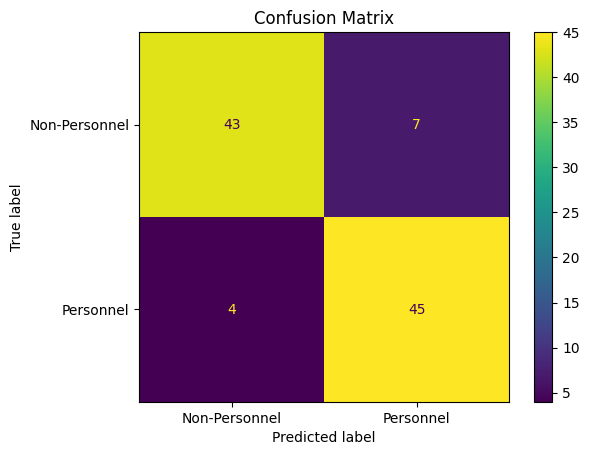

In [228]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["Non-Personnel", "Personnel"]

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=labels,
    display_labels=labels
)

plt.title("Confusion Matrix")
plt.show()

## 10. Review Misclassified Examples

*   I review misclassified test examples to understand where the baseline model makes errors and what types of text patterns may require future human review or additional domain rules.

In [229]:
error_df = pd.DataFrame({
    "raw_text": df.loc[X_test.index, "raw_text"],
    "clean_text": X_test,
    "actual": y_test,
    "predicted": y_pred
})

misclassified = error_df[error_df["actual"] != error_df["predicted"]]

print("Number of misclassified examples:", len(misclassified))
display(misclassified)

Number of misclassified examples: 11


,raw_text,clean_text,actual,predicted
325,WC BLDG 1,wc bldg 1,Personnel,Non-Personnel
255,DEPUTY SUPT / PSERS FY25,deputy supt psers fy25,Personnel,Non-Personnel
114,ASBESTOS ABATE RM 12B,asbestos abate rm 12b,Non-Personnel,Personnel
389,LAPTOP - JUL,laptop jul,Non-Personnel,Personnel
417,DISPLAY ACCT 6120,display acct 6120,Non-Personnel,Personnel
22,WORK COMP - LIBRARIAN BLDG 1.,work comp librarian bldg 1,Personnel,Non-Personnel
30,TCHR TRAINING BOOKS GR 5,teacher training books gr 5,Non-Personnel,Personnel
385,WATER RM 302,water rm 302,Non-Personnel,Personnel
483,COMPUTER ACCT 5410,computer acct 5410,Non-Personnel,Personnel
405,AP-STRS 47.,ap strs 47,Personnel,Non-Personnel


## 11. Low-Confidence Prediction Review

*   Because the classifier is Logistic Regression, I can inspect predicted class probabilities. In a production workflow, records with low maximum predicted probability could be routed to a human analyst for review rather than being automatically finalized.
*   For demonstration, I sort records by predicted confidence and inspect the 10 lowest-confidence predictions. In production, a fixed threshold such as 0.60 or 0.70 could be used to trigger human review.



In [230]:
proba = model.predict_proba(X_test)
class_labels = model.classes_

confidence_df = error_df.copy()

for i, label in enumerate(class_labels):
    confidence_df[f"prob_{label}"] = proba[:, i]

confidence_df["predicted_confidence"] = proba.max(axis=1)

low_confidence = confidence_df.sort_values("predicted_confidence").head(10)

display(low_confidence)

,raw_text,clean_text,actual,predicted,prob_Non-Personnel,prob_Personnel,predicted_confidence
255,DEPUTY SUPT / PSERS FY25,deputy supt psers fy25,Personnel,Non-Personnel,0.505420,0.494580,0.505420
405,AP-STRS 47.,ap strs 47,Personnel,Non-Personnel,0.506651,0.493349,0.506651
483,COMPUTER ACCT 5410,computer acct 5410,Non-Personnel,Personnel,0.493209,0.506791,0.506791
385,WATER RM 302,water rm 302,Non-Personnel,Personnel,0.489800,0.510200,0.510200
220,SUB PARA Q4,sub para q4,Personnel,Personnel,0.486426,0.513574,0.513574
22,WORK COMP - LIBRARIAN BLDG 1.,work comp librarian bldg 1,Personnel,Non-Personnel,0.522112,0.477888,0.522112
309,SUPT / VISION LOC 22,supt vision loc 22,Personnel,Personnel,0.465730,0.534270,0.534270
389,LAPTOP - JUL,laptop jul,Non-Personnel,Personnel,0.463989,0.536011,0.536011
295,INSTR COACH HOURLY SCH 07,instr coach hourly sch 07,Personnel,Personnel,0.456360,0.543640,0.543640
323,SMARTBRD,smartbrd,Non-Personnel,Non-Personnel,0.548843,0.451157,0.548843


## 12. Summary

This notebook builds a reproducible baseline text classification pipeline for labeling school finance ledger descriptions as Personnel or Non-Personnel expenses. The final model uses rule-based text preprocessing, TF-IDF vectorization, and Logistic Regression. On the held-out test set, the model achieves balanced performance across both classes. Misclassified and low-confidence records are reviewed to identify examples that may require future domain rules or human analyst review.

## 13. Data Mutation Layout Diagram

The following diagram maps how a single raw ledger string changes state as it moves through the classification pipeline, from raw text preprocessing to TF-IDF vectorization, model prediction, confidence review, and potential human analyst override.

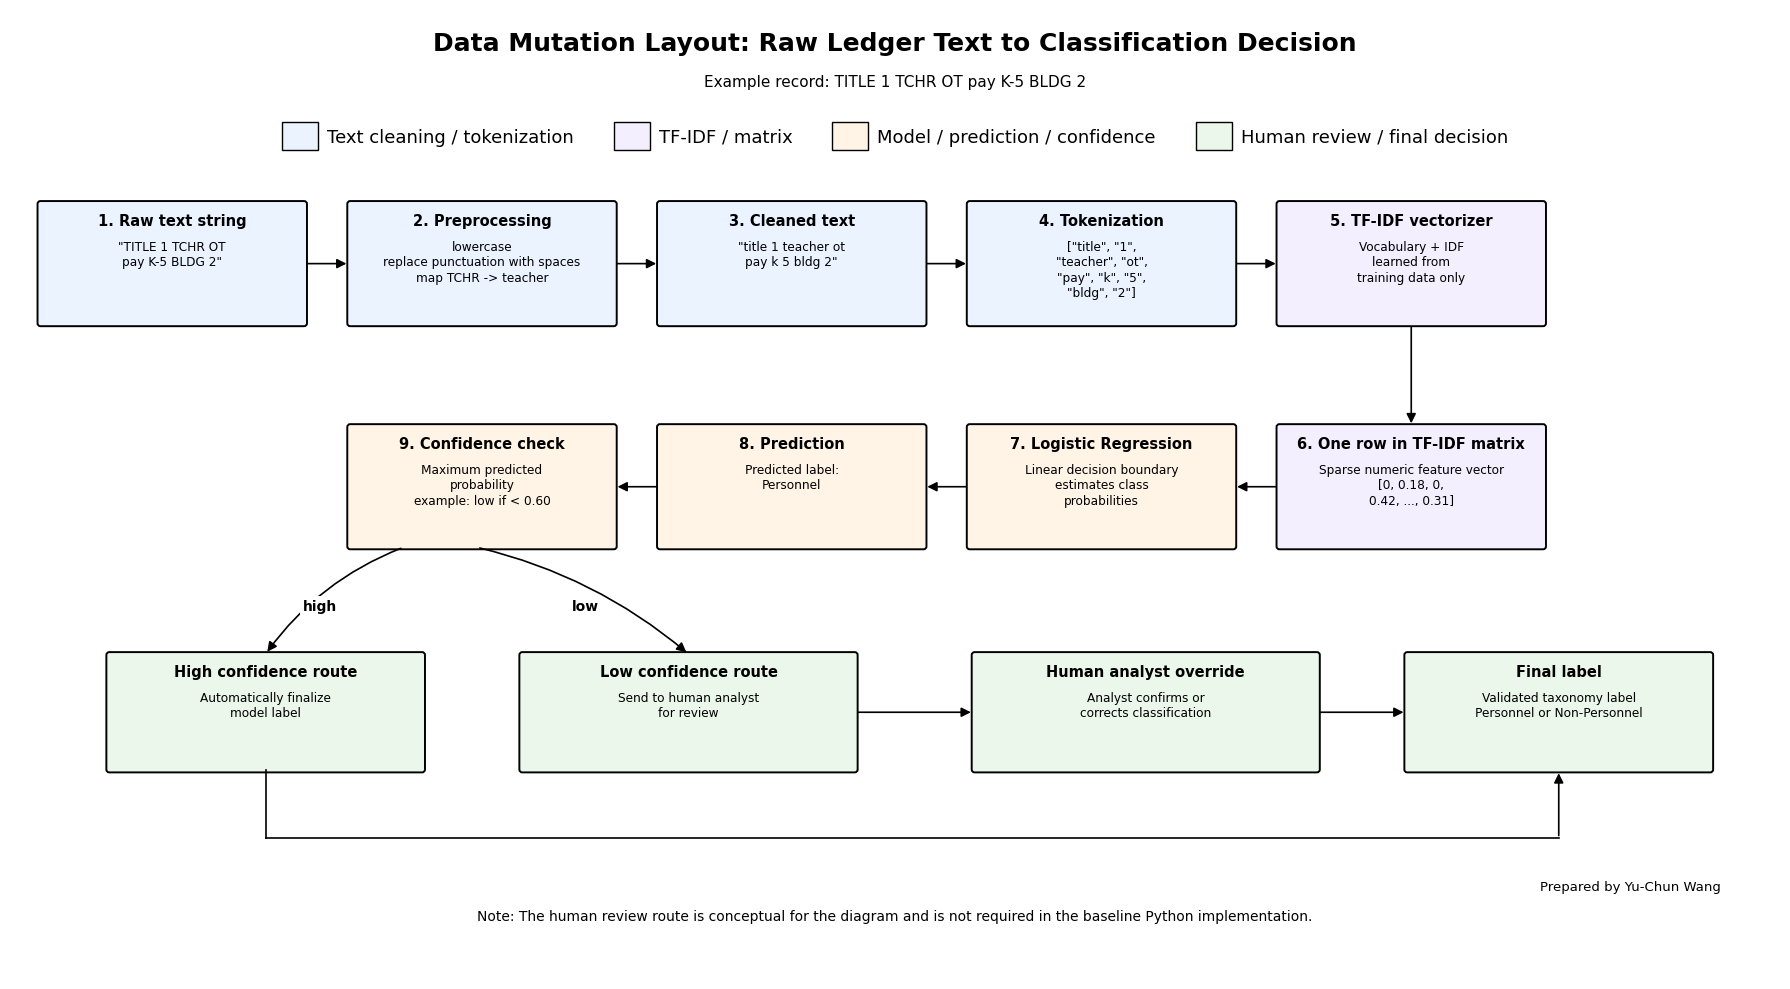

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Patch
try:
    from google.colab import files
except ImportError:
    files = None

# Soft color palette
TEXT_COLOR = "#EAF3FF"       # light blue
VECTOR_COLOR = "#F3EFFF"     # light purple
MODEL_COLOR = "#FFF4E6"      # light orange
REVIEW_COLOR = "#EAF7EA"     # light green


def add_box(
    ax,
    x,
    y,
    w,
    h,
    title,
    body,
    facecolor="white",
    fontsize_title=10.5,
    fontsize_body=8.7
):
    """
    Add a rounded text box to the diagram.
    """
    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.02,rounding_size=0.03",
        linewidth=1.4,
        edgecolor="black",
        facecolor=facecolor
    )
    ax.add_patch(box)

    # Title
    ax.text(
        x + w / 2,
        y + h - 0.10,
        title,
        ha="center",
        va="top",
        fontsize=fontsize_title,
        fontweight="bold"
    )

    # Body text
    ax.text(
        x + w / 2,
        y + h - 0.38,
        body,
        ha="center",
        va="top",
        fontsize=fontsize_body,
        linespacing=1.25
    )


def add_arrow(ax, start, end, text=None, text_offset=(0, 0), connectionstyle="arc3,rad=0"):
    """
    Add a single arrow between two points.
    """
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=1.2,
        color="black",
        connectionstyle=connectionstyle
    )
    ax.add_patch(arrow)

    if text:
        ax.text(
            (start[0] + end[0]) / 2 + text_offset[0],
            (start[1] + end[1]) / 2 + text_offset[1],
            text,
            ha="center",
            va="center",
            fontsize=8.5
        )


def add_polyline_arrow(ax, points, linewidth=1.2):
    """
    Add a multi-segment arrow. Intermediate segments are plain lines;
    the final segment has the arrowhead.
    """
    for i in range(len(points) - 2):
        x_values = [points[i][0], points[i + 1][0]]
        y_values = [points[i][1], points[i + 1][1]]
        ax.plot(x_values, y_values, color="black", linewidth=linewidth)

    add_arrow(ax, points[-2], points[-1])


# Create figure
fig, ax = plt.subplots(figsize=(18, 10))
ax.set_xlim(0, 18)
ax.set_ylim(0, 10)
ax.axis("off")

# Title
ax.text(
    9,
    9.65,
    "Data Mutation Layout: Raw Ledger Text to Classification Decision",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold"
)

ax.text(
    9,
    9.25,
    "Example record: TITLE 1 TCHR OT pay K-5 BLDG 2",
    ha="center",
    va="center",
    fontsize=11
)

# Legend
legend_elements = [
    Patch(facecolor=TEXT_COLOR, edgecolor="black", label="Text cleaning / tokenization"),
    Patch(facecolor=VECTOR_COLOR, edgecolor="black", label="TF-IDF / matrix"),
    Patch(facecolor=MODEL_COLOR, edgecolor="black", label="Model / prediction / confidence"),
    Patch(facecolor=REVIEW_COLOR, edgecolor="black", label="Human review / final decision")
]

ax.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.90),
    ncol=4,
    frameon=False,
    fontsize=13,
    handlelength=2.0,
    handleheight=2.0,
    columnspacing=2.2,
    handletextpad=0.5
)

# Box settings
w, h = 2.7, 1.25
y_main = 6.75
y_second = 4.45
y_bottom = 2.15

# Top row: text transformation
add_box(
    ax, 0.3, y_main, w, h,
    "1. Raw text string",
    '"TITLE 1 TCHR OT\npay K-5 BLDG 2"',
    facecolor=TEXT_COLOR
)

add_box(
    ax, 3.45, y_main, w, h,
    "2. Preprocessing",
    "lowercase\nreplace punctuation with spaces\nmap TCHR -> teacher",
    facecolor=TEXT_COLOR
)

add_box(
    ax, 6.6, y_main, w, h,
    "3. Cleaned text",
    '"title 1 teacher ot\npay k 5 bldg 2"',
    facecolor=TEXT_COLOR
)

add_box(
    ax, 9.75, y_main, w, h,
    "4. Tokenization",
    '["title", "1",\n"teacher", "ot",\n"pay", "k", "5",\n"bldg", "2"]',
    facecolor=TEXT_COLOR
)

# Vectorization
add_box(
    ax, 12.9, y_main, w, h,
    "5. TF-IDF vectorizer",
    "Vocabulary + IDF\nlearned from\ntraining data only",
    facecolor=VECTOR_COLOR
)

add_box(
    ax, 12.9, y_second, w, h,
    "6. One row in TF-IDF matrix",
    "Sparse numeric feature vector\n[0, 0.18, 0,\n0.42, ..., 0.31]",
    facecolor=VECTOR_COLOR
)

# Model and prediction
add_box(
    ax, 9.75, y_second, w, h,
    "7. Logistic Regression",
    "Linear decision boundary\nestimates class\nprobabilities",
    facecolor=MODEL_COLOR
)

add_box(
    ax, 6.6, y_second, w, h,
    "8. Prediction",
    "Predicted label:\nPersonnel",
    facecolor=MODEL_COLOR
)

add_box(
    ax, 3.45, y_second, w, h,
    "9. Confidence check",
    "Maximum predicted\nprobability\nexample: low if < 0.60",
    facecolor=MODEL_COLOR
)

# Review / final decision workflow
add_box(
    ax, 1.0, y_bottom, 3.2, 1.2,
    "High confidence route",
    "Automatically finalize\nmodel label",
    facecolor=REVIEW_COLOR
)

add_box(
    ax, 5.2, y_bottom, 3.4, 1.2,
    "Low confidence route",
    "Send to human analyst\nfor review",
    facecolor=REVIEW_COLOR
)

add_box(
    ax, 9.8, y_bottom, 3.5, 1.2,
    "Human analyst override",
    "Analyst confirms or\ncorrects classification",
    facecolor=REVIEW_COLOR
)

add_box(
    ax, 14.2, y_bottom, 3.1, 1.2,
    "Final label",
    "Validated taxonomy label\nPersonnel or Non-Personnel",
    facecolor=REVIEW_COLOR
)

# Main pipeline arrows: top row
add_arrow(ax, (3.0, y_main + h / 2), (3.45, y_main + h / 2))
add_arrow(ax, (6.15, y_main + h / 2), (6.6, y_main + h / 2))
add_arrow(ax, (9.3, y_main + h / 2), (9.75, y_main + h / 2))
add_arrow(ax, (12.45, y_main + h / 2), (12.9, y_main + h / 2))

# Down from TF-IDF vectorizer to TF-IDF matrix row
add_arrow(ax, (14.25, y_main), (14.25, y_second + h))

# Second row arrows: right to left
add_arrow(ax, (12.9, y_second + h / 2), (12.45, y_second + h / 2))
add_arrow(ax, (9.75, y_second + h / 2), (9.3, y_second + h / 2))
add_arrow(ax, (6.6, y_second + h / 2), (6.15, y_second + h / 2))

# Confidence split arrows
add_arrow(
    ax,
    (4.0, y_second),
    (2.6, y_bottom + 1.2),
    connectionstyle="arc3,rad=0.15"
)

add_arrow(
    ax,
    (4.75, y_second),
    (6.9, y_bottom + 1.2),
    connectionstyle="arc3,rad=-0.12"
)

# High / low labels beside the arrows
ax.text(
    3.15,
    3.85,
    "high",
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold",
    bbox=dict(facecolor="white", edgecolor="none", pad=2)
)

ax.text(
    5.85,
    3.85,
    "low",
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold",
    bbox=dict(facecolor="white", edgecolor="none", pad=2)
)

# Low-confidence route: analyst review path
add_arrow(ax, (8.6, y_bottom + 0.6), (9.8, y_bottom + 0.6))
add_arrow(ax, (13.3, y_bottom + 0.6), (14.2, y_bottom + 0.6))

# High-confidence route: go below all boxes, then directly to final label
high_route_y = 1.45

add_polyline_arrow(
    ax,
    [
        (2.6, y_bottom),          # bottom center of high confidence box
        (2.6, high_route_y),      # go down
        (15.75, high_route_y),    # move horizontally below all boxes
        (15.75, y_bottom)         # go up into final label box
    ]
)

# Add author name
ax.text(
    17.4,
    0.95,
    "Prepared by Yu-Chun Wang",
    ha="right",
    va="center",
    fontsize=9.5
)

# Footnote
ax.text(
    9,
    0.65,
    "Note: The human review route is conceptual for the diagram and is not required in the baseline Python implementation.",
    ha="center",
    va="center",
    fontsize=10
)

plt.tight_layout()

# Save files
png_path = "YuChunWang_Data_Mutation_Layout.png"
pdf_path = "YuChunWang_Data_Mutation_Layout.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")

# Show inside notebook
plt.show()

# Download files in Colab
# files.download(png_path)
# files.download(pdf_path)